# Setup and Installation

Run this cell first to ensure all required packages are installed.

In [ ]:
import sys
import subprocess

def install_requirements():
    """
    Install all required packages for the fraud detection notebook.
    This includes data processing, machine learning, and visualization libraries.
    """
    
    # Core data science packages
    packages = [
        'pandas',                    # Data manipulation and analysis
        'numpy',                     # Numerical computing
        'scikit-learn',              # Machine learning algorithms
        'matplotlib',                # Plotting and visualization
        'seaborn',                   # Statistical data visualization
        'tqdm',                      # Progress bars
        
        # Deep learning and graph neural networks
        'torch',                     # PyTorch deep learning framework
        'torch-geometric',           # Graph Neural Network library
        'torch-scatter',             # Scatter operations for PyTorch
        'torch-sparse',              # Sparse tensor operations
        
        # Data download and file handling
        'kagglehub',                 # Kaggle dataset downloads
        'gdown',                     # Google Drive file downloads
        
        # Graph visualization
        'networkx',                  # Graph/network analysis
        'pyvis',                     # Interactive network visualizations
    ]
    
    print("="*80)
    print("INSTALLING REQUIRED PACKAGES FOR FRAUD DETECTION NOTEBOOK")
    print("="*80)
    print(f"\nTotal packages to install: {len(packages)}\n")
    
    for i, package in enumerate(packages, 1):
        print(f"[{i}/{len(packages)}] Installing {package}...")
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", package],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.PIPE
            )
            print(f"  ✓ {package} installed successfully")
        except subprocess.CalledProcessError as e:
            print(f"  ⚠ Warning: Failed to install {package}")
            print(f"    Error: {e.stderr.decode() if e.stderr else 'Unknown error'}")
    
    print("\n" + "="*80)
    print("INSTALLATION COMPLETE")
    print("="*80)
    print("\n✓ All packages installed. You can now run the notebook cells below.")
    print("\nNote: If you encounter any import errors, you may need to restart the kernel.")

# Run the installation
install_requirements()

## Alternative Installation Methods

**Option 1: Run the cell above** - Installs packages directly from within the notebook.

**Option 2: Use requirements.txt** - Install from command line:
```bash
pip install -r requirements.txt
```

**Option 3: Individual packages** - Install specific packages:
```bash
pip install pandas numpy torch torch-geometric scikit-learn matplotlib networkx pyvis kagglehub gdown tqdm
```

**Important Notes:**
- PyTorch Geometric (`torch-geometric`) may require additional dependencies (`torch-scatter`, `torch-sparse`) depending on your system
- For GPU support, install the CUDA-enabled version of PyTorch from [pytorch.org](https://pytorch.org)
- After installation, restart the kernel to ensure all packages are properly loaded

# Download banksim dataset from kaggle

**Citation:** Lopez-Rojas, Edgar Alonso; Axelsson, Stefan. *Banksim: A bank payments simulator for fraud detection research*. Inproceedings 26th European Modeling and Simulation Symposium, EMSS 2014, Bordeaux, France, pp. 144–152, Dime University of Genoa, 2014, ISBN: 9788897999324. https://www.researchgate.net/publication/265736405_BankSim_A_Bank_Payment_Simulation_for_Fraud_Detection_Research

In [2]:
import kagglehub
import os
import shutil
from csv_to_gzip import csv_to_gzip

# Check for required files in banksim directory
files_to_check = [
    "banksim/bs140513_032310.csv.gz",
    "banksim/bsNET140513_032310.csv.gz"
]

files_exist = all(os.path.exists(f) for f in files_to_check)

if files_exist:
    print("Both required files found. Skipping download.")
else:
    print("Required files missing. Downloading dataset...")
    path = kagglehub.dataset_download("ealaxi/banksim1")
    shutil.copytree(path, "banksim", dirs_exist_ok=True)
    print("Downloaded dataset to 'banksim'.")
    
    # Compress CSV files to gzip
    for csv_file in ['bs140513_032310.csv', 'bsNET140513_032310.csv']:
        csv_path = os.path.join("banksim", csv_file)
        if os.path.exists(csv_path):
            csv_to_gzip(csv_path)
            print(f"Compressed {csv_file} to {csv_file}.gz")

print("Path to dataset files:", "banksim")

Both required files found. Skipping download.
Path to dataset files: banksim


In [3]:
import os
import pandas as pd

# List files in the banksim dataset directory
banksim_path = "banksim"
banksim_files = os.listdir("banksim")
print(f"Files in banksim dataset directory:\n")

for file in banksim_files:
    file_path = os.path.join(banksim_path, file)
    print(f"{'='*50}")
    print(f"File: {file}")
    print(f"{'='*50}")
    
    if file.endswith('.csv.gz'):
        df_temp = pd.read_csv(file_path)
        print(f"Shape: {df_temp.shape}")
        print(f"Columns: {list(df_temp.columns)}")
        print(f"\nFirst few rows:\n{df_temp.head()}")
        print(f"\nData types:\n{df_temp.dtypes}")

        # Count fraud and non-fraud in the banksim dataset
        fraud_count = (df_temp['fraud'] == 1).sum()
        non_fraud_count = (df_temp['fraud'] == 0).sum()

        print("BankSim Dataset - Fraud Distribution:")
        print(f"  Fraud: {fraud_count}")
        print(f"  Non-Fraud: {non_fraud_count}")
        print(f"  Total: {len(df_temp)}")
        print(f"  Fraud Percentage: {fraud_count / len(df_temp) * 100:.2f}%")
    else:
        print(f"File type: {os.path.splitext(file)[1]}")
        print(f"File size: {os.path.getsize(file_path)} bytes")
    
    print("\n")


Files in banksim dataset directory:

File: bsNET140513_032310.csv.gz
Shape: (594643, 5)
Columns: ['Source', 'Target', 'Weight', 'typeTrans', 'fraud']

First few rows:
          Source         Target  Weight            typeTrans  fraud
0  'C1093826151'   'M348934600'    4.55  'es_transportation'      0
1   'C352968107'   'M348934600'   39.68  'es_transportation'      0
2  'C2054744914'  'M1823072687'   26.89  'es_transportation'      0
3  'C1760612790'   'M348934600'   17.25  'es_transportation'      0
4   'C757503768'   'M348934600'   35.72  'es_transportation'      0

Data types:
Source        object
Target        object
Weight       float64
typeTrans     object
fraud          int64
dtype: object
BankSim Dataset - Fraud Distribution:
  Fraud: 7200
  Non-Fraud: 587443
  Total: 594643
  Fraud Percentage: 1.21%


File: bs140513_032310.csv.gz
Shape: (594643, 10)
Columns: ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']

First fe

# Download the scotiabank data files

In [ ]:
import gdown
import zipfile
import os
from csv_to_gzip import csv_to_gzip

data_path = "data"
# Check for required files in data directory
files_to_check = [
    "data/labels.csv.gz",
    "data/kyc_individual.csv.gz",
    "data/kyc_smallbusiness.csv.gz",
    "data/card.csv.gz"
]

files_exist = all(os.path.exists(f) for f in files_to_check)
files_exist = files_exist and os.path.isdir(data_path) and len(os.listdir(data_path)) == 12

if files_exist:
    print("Required files found. Skipping download.")
else:
    print("Required files missing. Downloading dataset...")
    
    # Download data.zip
    url = "https://drive.google.com/file/d/1A7w3GqZTCVsv-A8gXj5NKV2FNc0zoduG/view?usp=sharing"
    zip_path = "data.zip"

    print("Downloading data.zip...")
    gdown.download(url, zip_path, fuzzy=True)
    print("Download complete.")

    # Extract the zip file
    print("Extracting data.zip...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data")
    print("Extraction complete.")

    # Compress all CSV files in the data directory to .csv.gz
    print("Compressing CSV files to gzip...")
    for filename in os.listdir(data_path):
        if filename.endswith('.csv'):
            csv_path = os.path.join(data_path, filename)
            csv_to_gzip(csv_path)
            print(f"Compressed {filename} to {filename}.gz")
            os.remove(csv_path)

    # Clean up the zip file
    os.remove(zip_path)
    print("Cleaned up data.zip")

print("Data files ready in 'data' directory")


Required files found. Skipping download.
Data files ready in 'data' directory


# Prepare transaction nodes for Graph Attention Network

Combine the BankSim and Scotiabank transactions into a unified master pool aligned to the card schema:

**Schema**
[transaction_id, customer_id, amount_cad, debit_credit, transaction_datetime, merchant_category, ecommerce_ind, cash_indicator, country, province, city, is_fraud, source_dataset, time_delta, velocity_24h, cust_idx, cat_idx, city_idx]

**Field definitions**
- **transaction_id**: Unique transaction identifier (BankSim uses `BS_{i}`).
- **customer_id**: Unique customer identifier.
- **amount_cad**: Transaction amount in CAD (BankSim amounts multiplied by 1.62 from EUR).
- **debit_credit**: Debit/credit flag (BankSim uses `debit`; Scotiabank uses source values).
- **transaction_datetime**: Transaction timestamp (BankSim derived from `step`).
- **merchant_category**: Mapped industry category or transfer type.
- **ecommerce_ind**: 1 if e-commerce (e.g., tech/content), else 0.
- **cash_indicator**: 1 for cash-like activity (ABM), else 0.
- **country/province/city**: Location fields (BankSim defaults to Canada/Ontario/Toronto; transfers use N/A).
- **is_fraud**: Fraud label (BankSim from `fraud`; Scotiabank from `labels`, default -1 if unknown).
- **source_dataset**: Origin dataset (banksim, scotia_card, scotia_abm, scotia_transfer).
- **time_delta**: Minutes since the customer’s previous transaction (0 for first transaction).
- **velocity_24h**: Count of customer transactions in the trailing 24 hours (including current).
- **cust_idx/cat_idx/city_idx**: Integer-encoded indices for graph nodes.

In [15]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

def get_mapping(series):
    unique_vals = series.unique()
    return {val: i for i, val in enumerate(unique_vals)}, len(unique_vals)

def build_master_transaction_pool(banksim_path, data_path):

    # Prepare banksim
    bs = pd.read_csv(os.path.join(banksim_path, 'bs140513_032310.csv.gz'))
    bs.columns = bs.columns.str.replace("'", "")
    for col in bs.select_dtypes('object'):
        bs[col] = bs[col].str.replace("'", "")
    
    start_date = datetime(year=2024, month=11, day=1)
    bs['transaction_datetime'] = bs['step'].apply(lambda x: start_date + timedelta(days=x))
    
    # Updated mapping to closest industry names present in kyc_industry_codes
    cat_map = {
        'es_transportation': 'Taxicab Industry', 'es_food': 'Food (Groceries) Stores',
        'es_health': 'Offices of Physicians, General Practice', 
        'es_wellnessandbeauty': 'Combination Barber and Beauty shops',
        'es_fashion': "Women's Clothing Stores", 'es_barsandrestaurants': 'Restaurants, Licensed',
        'es_hyper': 'General Stores', 'es_sportsandtoys': 'Sporting Goods Stores',
        'es_tech': 'Computer Services', 'es_home': 'Other Household Furnishings Stores',
        'es_hotelservices': 'Hotels and Motor Hotels', 'es_otherservices': 'Other Services n.e.c.',
        'es_contents': 'Other Publishing Industries', 'es_travel': 'Tour Wholesalers and Operators', 
        'es_leisure': 'Other Amusement and Recreational Services n.e.c.'
    }
    
    print("Banksim finished")
    bs_master = pd.DataFrame({
        'transaction_id': [f"BS_{i}" for i in range(len(bs))],
        'customer_id': bs['customer'],
        'amount_cad': bs['amount'] * 1.62,
        'debit_credit': 'debit',
        'transaction_datetime': bs['transaction_datetime'],
        'merchant_category': bs['category'].map(cat_map),
        'ecommerce_ind': np.where(bs['category'].isin(['es_tech', 'es_contents']), 1, 0),
        'cash_indicator': 0, 
        'country': 'Canada', 'province': 'Ontario', 'city': 'Toronto', # BankSim is all Zip 28007
        'is_fraud': bs['fraud'],
        'source_dataset': 'banksim'
    })

    # Load scotiabank data
    labels_df = pd.read_csv(os.path.join(data_path, 'labels.csv.gz'))
    print("Labels finished")
    card_df = pd.read_csv(os.path.join(data_path, 'card.csv.gz'))
    print("card finished")
    abm_df = pd.read_csv(os.path.join(data_path, 'abm.csv.gz'))
    print("abm finished")
    cheque_df = pd.read_csv(os.path.join(data_path, 'cheque.csv.gz'))
    print("cheque finished")
    eft_df = pd.read_csv(os.path.join(data_path, 'eft.csv.gz'))
    print("eft finished")
    emt_df = pd.read_csv(os.path.join(data_path, 'emt.csv.gz'))
    print("emt finished")
    westernunion_df = pd.read_csv(os.path.join(data_path, 'westernunion.csv.gz'))
    print("westernunion finished")
    wire_df = pd.read_csv(os.path.join(data_path, 'wire.csv.gz'))
    print("wire finished")

    # Card
    card_master = card_df.copy()
    card_master['source_dataset'] = 'scotia_card'
    card_master['cash_indicator'] = 0
    card_master = card_master.merge(labels_df[['customer_id', 'label']], on='customer_id', how='left')
    card_master['is_fraud'] = card_master['label'].fillna(-1).astype(int)
    card_master.drop(columns=['label'], inplace=True)

    # ABM 
    abm_master = abm_df.copy()
    abm_master['merchant_category'] = 'ATM_WITHDRAWAL'
    abm_master['ecommerce_ind'] = 0
    abm_master['source_dataset'] = 'scotia_abm'
    # ABM is almost always a cash transaction
    abm_master['cash_indicator'] = 1 
    abm_master = abm_master.merge(labels_df[['customer_id', 'label']], on='customer_id', how='left')
    abm_master['is_fraud'] = abm_master['label'].fillna(-1).astype(int)
    abm_master.drop(columns=['label'], inplace=True)

    # Others that have the same columns
    cheque_df['merchant_category'] = 'CHEQUE'
    eft_df['merchant_category'] = 'EFT_TRANSFER'
    emt_df['merchant_category'] = 'INTERAC_EMT'
    westernunion_df['merchant_category'] = 'WESTERN_UNION'
    wire_df['merchant_category'] = 'WIRE_TRANSFER'

    others = pd.concat([cheque_df, eft_df, emt_df, westernunion_df, wire_df], axis=0)
    others['ecommerce_ind'] = 0
    others['cash_indicator'] = 0
    others['country'], others['province'], others['city'] = 'Canada', 'N/A', 'N/A'
    others['source_dataset'] = 'scotia_transfer'
    
    others = others.merge(labels_df[['customer_id', 'label']], on='customer_id', how='left')
    others['is_fraud'] = others['label'].fillna(-1).astype(int)
    others.drop(columns=['label'], inplace=True)

    # Merge
    master_pool = pd.concat([bs_master, card_master, abm_master, others], axis=0, ignore_index=True)
    print("Merge finished")
    master_pool['city'] = master_pool['city'].str.upper().fillna('UNKNOWN')

    master_pool['transaction_datetime'] = pd.to_datetime(master_pool['transaction_datetime'], format='mixed')
    master_pool = master_pool.sort_values(['customer_id', 'transaction_datetime']).reset_index(drop=True)

    # Calculate time delta since last transaction (in minutes)
    master_pool['time_delta'] = master_pool.groupby('customer_id')['transaction_datetime'].diff().dt.total_seconds() / 60
    master_pool['time_delta'] = master_pool['time_delta'].fillna(0)  # First transaction has no delta
    print("Computed time delta")

    # Calculate 24-hour velocity (transaction count in past 24 hours including current)
    master_pool['velocity_24h'] = (
        master_pool.groupby('customer_id', group_keys=False)
        .rolling(window='24H', on='transaction_datetime')['transaction_id']
        .count()
        .droplevel(0)  # Drop customer_id level from MultiIndex
        .values  # Extract values to avoid index alignment issues
    )
    print("Computed 24h velocity")
    
    return master_pool

def get_maps(master_pool):
    cust_map, num_cust = get_mapping(master_pool['customer_id'])
    cat_map, num_cat = get_mapping(master_pool['merchant_category'])
    city_map, num_city = get_mapping(master_pool['city'].str.upper().fillna('UNKNOWN'))
    master_pool['cust_idx'] = master_pool['customer_id'].map(cust_map)
    master_pool['cat_idx'] = master_pool['merchant_category'].map(cat_map)
    master_pool['city_idx'] = master_pool['city'].str.upper().fillna('UNKNOWN').map(city_map)
    return cust_map, cat_map, city_map, num_cust, num_cat, num_city

master_path = "master_transaction_pool.csv.gz"
if not os.path.exists(master_path):
    print("Building master transaction pool")
    master_pool = build_master_transaction_pool(banksim_path, data_path)
    print("Mapping started")
    cust_map, cat_map, city_map, num_cust, num_cat, num_city = get_maps(master_pool)
    print("Saving started")
    master_pool.to_csv(master_path, index=False, compression="gzip")
else:
    print("Reading started")
    master_pool = pd.read_csv(master_path, compression="gzip")
    print("Mapping started")
    cust_map, cat_map, city_map, num_cust, num_cat, num_city = get_maps(master_pool)
master_pool.head()

Building master transaction pool
Banksim finished
Labels finished
card finished
abm finished
cheque finished
eft finished
emt finished
westernunion finished
wire finished
Merge finished
Computed time delta


/tmp/ipykernel_302375/839157751.py:118: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  master_pool.groupby('customer_id', group_keys=False)
/tmp/ipykernel_302375/839157751.py:118: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  master_pool.groupby('customer_id', group_keys=False)


Computed 24h velocity
Mapping started
Saving started


,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,merchant_category,ecommerce_ind,cash_indicator,country,province,city,is_fraud,source_dataset,time_delta,velocity_24h,cust_idx,cat_idx,city_idx
0,BS_80563,C1000148617,233.0694,debit,2024-12-01,Other Services n.e.c.,0,0,Canada,Ontario,TORONTO,0,banksim,0.0,1.0,0,0,0
1,BS_105386,C1000148617,27.0378,debit,2024-12-09,Sporting Goods Stores,0,0,Canada,Ontario,TORONTO,0,banksim,11520.0,1.0,0,1,0
2,BS_117326,C1000148617,91.0116,debit,2024-12-13,Other Services n.e.c.,0,0,Canada,Ontario,TORONTO,0,banksim,5760.0,1.0,0,0,0
3,BS_120414,C1000148617,23.8788,debit,2024-12-14,Computer Services,1,0,Canada,Ontario,TORONTO,0,banksim,1440.0,1.0,0,2,0
4,BS_124902,C1000148617,76.8204,debit,2024-12-15,Taxicab Industry,0,0,Canada,Ontario,TORONTO,0,banksim,1440.0,1.0,0,3,0


# Prepare customer nodes for Graph Attention Network

We group individual customers and small businesses into one node type for simplicity. 

**Schema:** customer_id, age, income, tenure, sales, emp_count, is_biz

**Field definitions**
- **customer_id**: Unique customer identifier across KYC and BankSim sources.
- **age**: Customer age (years); derived from KYC birth dates or BankSim age buckets, with median imputation for missing.
- **income**: Annual income (or reported income proxy); missing values filled with the KYC median.
- **tenure**: Customer tenure in days since onboarding; defaults to 730 days if unknown.
- **sales**: Annual sales for small businesses; 0 for individuals, median-imputed when missing.
- **emp_count**: Number of employees for small businesses; 0 for individuals, median-imputed when missing.
- **is_biz**: 1 for small business customers, 0 for individuals.

In [12]:
# Build customers_df by merging KYC individuals + small businesses, then add BankSim customers
# Expected columns: ['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']

# Helper to compute tenure if onboard_date exists
def compute_tenure_days(df, date_col='onboard_date'):
    if date_col in df.columns:
        return (pd.Timestamp('2025-01-31') - pd.to_datetime(df[date_col], errors='coerce')).dt.days
    return pd.Series([np.nan] * len(df))

def build_customer_transaction_pool():
    # Load KYC data
    kyc_ind = pd.read_csv(os.path.join(data_path, 'kyc_individual.csv.gz'))
    kyc_biz = pd.read_csv(os.path.join(data_path, 'kyc_smallbusiness.csv.gz'))

    # Normalize column names
    kyc_ind.columns = kyc_ind.columns.str.lower()
    kyc_biz.columns = kyc_biz.columns.str.lower()

    # Prefer birth_date-derived ages when available
    if 'birth_date' in kyc_ind.columns:
        birth_dates = pd.to_datetime(kyc_ind['birth_date'], errors='coerce')
        derived_age = (pd.Timestamp('2025-01-31') - birth_dates).dt.days / 365.25
        if 'age' in kyc_ind.columns:
            raw_age = pd.to_numeric(kyc_ind['age'], errors='coerce')
            ind_age = raw_age.fillna(derived_age)
        else:
            ind_age = derived_age
    else:
        if 'age' in kyc_ind.columns:
            ind_age = pd.to_numeric(kyc_ind['age'], errors='coerce')
        else:
            ind_age = pd.Series([np.nan] * len(kyc_ind))

    # Prepare individuals
    ind = pd.DataFrame({
        'customer_id': kyc_ind['customer_id'].astype(str),
        'age': ind_age,
        'income': kyc_ind.get('income', np.nan),
        'tenure': compute_tenure_days(kyc_ind),
        'sales': 0.0,
        'emp_count': 0.0,
        'is_biz': 0
    })

    # Prepare small businesses
    biz = pd.DataFrame({
        'customer_id': kyc_biz['customer_id'].astype(str),
        'age': np.nan,
        'income': kyc_biz.get('income', np.nan),
        'tenure': compute_tenure_days(kyc_biz),
        'sales': kyc_biz.get('sales', 0.0),
        'emp_count': kyc_biz.get('emp_count', 0.0),
        'is_biz': 1
    })

    # Medians for imputation
    median_income = ind['income'].median()
    median_age = ind['age'].median()
    if pd.isna(median_age):
        median_age = 40.0
    median_sales = biz['sales'].median() if 'sales' in biz else 0.0
    median_emp = biz['emp_count'].median() if 'emp_count' in biz else 0.0

    # Fill missing in KYC
    for df in (ind, biz):
        df['income'] = df['income'].fillna(median_income)
        df['age'] = df['age'].fillna(median_age)
        df['tenure'] = df['tenure'].fillna(730)  # 2 years
        df['sales'] = df['sales'].fillna(median_sales)
        df['emp_count'] = df['emp_count'].fillna(median_emp)

    # Build BankSim customers with default values
    banksim = pd.read_csv(os.path.join(banksim_path, 'bs140513_032310.csv.gz'), usecols=['customer', 'age'])
    banksim['customer'] = banksim['customer'].astype(str)
    banksim['age'] = banksim['age'].astype(str).str.strip("'")

    # Map BankSim age categories to midpoints
    age_map = {
        '0': 18,   # <=18
        '1': 22,   # 19-25
        '2': 30,   # 26-35
        '3': 40,   # 36-45
        '4': 50,   # 46-55
        '5': 60,   # 56-65
        '6': 70,   # >65
        'U': median_age
    }
    banksim['age_num'] = banksim['age'].map(age_map).fillna(median_age)

    # Use BankSim customers present in master_pool
    banksim_customers = master_pool.loc[master_pool['source_dataset'] == 'banksim', 'customer_id'].astype(str).unique()
    banksim_age = banksim.drop_duplicates('customer').set_index('customer')['age_num']

    banksim_df = pd.DataFrame({
        'customer_id': banksim_customers,
        'age': [banksim_age.get(cid, median_age) for cid in banksim_customers],
        'income': median_income,
        'tenure': 730,
        'sales': 0.0,
        'emp_count': 0.0,
        'is_biz': 0
    })

    # Combine all customers
    customers_df = pd.concat([ind, biz, banksim_df], axis=0, ignore_index=True)

    # Rebuild ages from KYC + BankSim sources
    customers_df['age'] = customers_df['customer_id'].map(
        pd.concat([
            ind.set_index('customer_id')['age'],
            banksim_df.set_index('customer_id')['age']
        ])
    )
    customers_df['age'] = customers_df['age'].fillna(median_age)

    # Deduplicate and align to cust_map ordering
    customers_df['cust_idx'] = customers_df['customer_id'].map(cust_map)
    customers_df = customers_df.dropna(subset=['cust_idx'])
    customers_df = customers_df.sort_values('cust_idx').reset_index(drop=True)

    # Final cleanup
    customers_df[['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']] = customers_df[
        ['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']
    ].astype(float)

    return customers_df

cust_path = "customer_pool.csv.gz"
if not os.path.exists(cust_path):
    print("Building customer pool")
    customer_pool = build_customer_transaction_pool()
    customer_pool.to_csv(cust_path, index=False, compression="gzip")
else:
    customer_pool = pd.read_csv(cust_path, compression="gzip")
customer_pool.head()

,customer_id,age,income,tenure,sales,emp_count,is_biz,cust_idx
0,C1093826151,46.63655,35974.0,730.0,0.0,0.0,0.0,0
1,C352968107,46.63655,35974.0,730.0,0.0,0.0,0.0,1
2,C2054744914,46.63655,35974.0,730.0,0.0,0.0,0.0,2
3,C1760612790,46.63655,35974.0,730.0,0.0,0.0,0.0,3
4,C757503768,46.63655,35974.0,730.0,0.0,0.0,0.0,4


In [16]:
import torch

# Transaction Features
# [log_amount, ecommerce_ind, cash_indicator, velocity_24h, time_delta]
x_trans = torch.tensor(np.stack([
    np.log1p(master_pool['amount_cad']),
    master_pool['ecommerce_ind'],
    master_pool['cash_indicator'],
    # You'll need to calculate velocity/time_delta during your Day 3 processing
    master_pool['velocity_24h'], 
    master_pool['time_delta']
], axis=1), dtype=torch.float)

# Customer Features (Zero-padded Individual + Business)
# [Age, Income, Tenure, Sales, Employee_Count, Is_Business]
# (Assume you merged kyc_ind and kyc_biz into a 'customers_df')
x_cust = torch.tensor(customer_pool[['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']].values, dtype=torch.float)

# Hub Features (Start as Identity or simple constants)
x_cat = torch.eye(num_cat) # One-hot encoding for small number of categories
x_city = torch.eye(num_city)

In [17]:
import torch.nn as nn

def masked_weighted_loss(y_pred, y_true, pos_weight):
    """
    Masked weighted binary cross entropy loss for class imbalance
    Args:
        y_pred: predictions (logits)
        y_true: true labels (may contain -1 for unlabeled)
        pos_weight: weight for positive class
    """
    # Create a mask where label is NOT -1
    mask = (y_true != -1)
    
    # If no labeled nodes in this batch, return 0 loss
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True).to(y_pred.device)
    
    # Filter only the labeled nodes
    labeled_pred = y_pred[mask]
    labeled_true = y_true[mask].float()
    
    # Binary Cross Entropy with Logits with pos_weight for imbalance
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)(labeled_pred, labeled_true)

In [18]:
from torch_geometric.data import HeteroData
data = HeteroData()

# Add Nodes
data['customer'].x = x_cust
data['transaction'].x = x_trans
data['category'].x = x_cat
data['city'].x = x_city

# Add Edges (Source, Target)
data['transaction', 'to', 'customer'].edge_index = torch.stack([
    torch.tensor(master_pool.index, dtype=torch.long),
    torch.tensor(master_pool['cust_idx'].values, dtype=torch.long)
])

data['transaction', 'at', 'category'].edge_index = torch.stack([
    torch.tensor(master_pool.index, dtype=torch.long),
    torch.tensor(master_pool['cat_idx'].values, dtype=torch.long)
])

data['transaction', 'in', 'city'].edge_index = torch.stack([
    torch.tensor(master_pool.index, dtype=torch.long),
    torch.tensor(master_pool['city_idx'].values, dtype=torch.long)
])

# PyG requires reverse edges for bidirectional flow
import torch_geometric.transforms as T
data = T.ToUndirected()(data)

In [21]:
# Add labels and masks for customer nodes
# For this example, we'll create labels based on whether a customer has any fraudulent transactions

# Create customer-level labels (1 if customer has any fraud, 0 otherwise)
customer_fraud = master_pool.groupby('cust_idx')['is_fraud'].max().values
data['customer'].y = torch.tensor(customer_fraud, dtype=torch.float)

# Create train/val/test masks (80/10/10 split)
num_customers = num_cust
perm = torch.randperm(num_customers)

train_size = int(0.8 * num_customers)
val_size = int(0.1 * num_customers)

train_mask = torch.zeros(num_customers, dtype=torch.bool)
val_mask = torch.zeros(num_customers, dtype=torch.bool)
test_mask = torch.zeros(num_customers, dtype=torch.bool)

train_mask[perm[:train_size]] = True
val_mask[perm[train_size:train_size + val_size]] = True
test_mask[perm[train_size + val_size:]] = True

data['customer'].train_mask = train_mask
data['customer'].val_mask = val_mask
data['customer'].test_mask = test_mask

# Count labeled vs unlabeled customers
labeled_mask = (customer_fraud != -1)
num_labeled = labeled_mask.sum()
num_unlabeled = int(np.sum(np.logical_not(labeled_mask)))

print(f"Customer nodes: {num_customers}")
print(f"Train: {train_mask.sum()}, Val: {val_mask.sum()}, Test: {test_mask.sum()}")
print(f"Labeled customers: {num_labeled}, Unlabeled: {num_unlabeled}")
print(f"Fraud rate (labeled only): {customer_fraud[labeled_mask].mean():.4f}")

Customer nodes: 65522
Train: 52417, Val: 6552, Test: 6553
Labeled customers: 5112, Unlabeled: 60410
Fraud rate (labeled only): 0.2921


# Define the model

In [22]:
import torch.nn.functional as F
import torch
from torch_geometric.nn import GATv2Conv, HeteroConv, Linear

class FraudGAT(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, num_heads):
        super().__init__()
        # Use GATv2 for dynamic attention weights
        self.conv1 = HeteroConv({
            ('customer', 'rev_to', 'transaction'): GATv2Conv((-1, -1), hidden_channels, heads=num_heads, add_self_loops=False),
            ('category', 'rev_at', 'transaction'): GATv2Conv((-1, -1), hidden_channels, heads=num_heads, add_self_loops=False),
            ('city', 'rev_in', 'transaction'): GATv2Conv((-1, -1), hidden_channels, heads=num_heads, add_self_loops=False),
        }, aggr='sum')
        
        self.conv2 = HeteroConv({
            ('transaction', 'to', 'customer'): GATv2Conv((-1, -1), hidden_channels, heads=num_heads, add_self_loops=False),
        }, aggr='sum')

        # Final projection to 1 output (fraud probability)
        # Note: we multiply by num_heads because GATv2 concatenates head outputs
        self.lin = Linear(hidden_channels * num_heads, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # Layer 1: Update Transactions using info from Customer/Category/City
        # We keep a copy of the original x_dict to preserve nodes not updated here
        x_dict_out = self.conv1(x_dict, edge_index_dict)
        x_dict_out = {key: F.elu(x) for key, x in x_dict_out.items()}
        
        # Crucial: Merge the updated transaction features back with the original dict
        # so Layer 2 can find 'customer' nodes to map TO.
        for key in x_dict:
            if key not in x_dict_out:
                x_dict_out[key] = x_dict[key]

        # Layer 2: Update Customers using info from Transactions
        x_dict_final = self.conv2(x_dict_out, edge_index_dict)
        
        # Final ELU and Linear projection
        return self.lin(F.elu(x_dict_final['customer']))

In [23]:
# Create NeighborLoader for mini-batch training to avoid GPU OOM
from torch_geometric.loader import NeighborLoader

# Configuration for neighbor sampling
# Use smaller batch size and fewer neighbors to fit in GPU memory
BATCH_SIZE = 512  # Smaller batch size to reduce memory usage
NUM_NEIGHBORS = [10, 5]  # Sample 10 neighbors in first hop, 5 in second hop

print("Creating NeighborLoaders for mini-batch training...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Neighbor sampling: {NUM_NEIGHBORS}")

train_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
    input_nodes=('customer', data['customer'].train_mask),
    shuffle=True,
    num_workers=0  # CPU-based sampling
)

val_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
    input_nodes=('customer', data['customer'].val_mask),
    shuffle=False,
    num_workers=0
)

print(f"✓ Train loader created: ~{len(train_loader)} batches")
print(f"✓ Val loader created: ~{len(val_loader)} batches")

Creating NeighborLoaders for mini-batch training...
Batch size: 512
Neighbor sampling: [10, 5]


/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


✓ Train loader created: ~103 batches
✓ Val loader created: ~13 batches


# Training Loop

In [26]:
from tqdm import tqdm
import gc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FraudGAT(hidden_channels=32, out_channels=1, num_heads=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Keep data on CPU - NeighborLoader will move batches to GPU as needed
# Calculate pos_weight for class imbalance
initial_train_mask = data['customer'].train_mask.clone()
train_labels = data['customer'].y[initial_train_mask]
labeled_mask = train_labels != -1
fraud_count = (train_labels[labeled_mask] == 1).sum()
legit_count = (train_labels[labeled_mask] == 0).sum()
pos_weight = (legit_count / fraud_count).to(device)

print(f"Initial class distribution - Fraud: {fraud_count}, Legit: {legit_count}, Pos Weight: {pos_weight:.2f}")
print(f"Model: hidden_channels=32, num_heads=2")

# Training configuration
num_epochs = 50
FRAUD_THRESHOLD = 0.98  # High confidence for fraud
LEGIT_THRESHOLD = 0.02  # High confidence for legit
WARMUP_EPOCHS = 20     # Epochs before using pseudo-labels

# Track pseudo-labeling statistics
total_pseudo_labeled = 0

print("\nStarting training with NeighborLoader...")
for epoch in tqdm(range(num_epochs), desc="Training"):
    model.train()
    epoch_loss = 0
    num_batches = 0
    
    # Training loop with mini-batches from NeighborLoader
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass on batch subgraph
        out = model(batch.x_dict, batch.edge_index_dict)
        
        # Extract predictions for input customer nodes only (not sampled neighbors)
        batch_size = batch['customer'].batch_size  # Number of input customer nodes
        customer_out = out.squeeze()[:batch_size]  # Take only input nodes
        customer_y = batch['customer'].y[:batch_size]
        
        # Calculate loss on labeled nodes in batch
        labeled_mask = customer_y != -1
        if labeled_mask.sum() > 0:
            loss = masked_weighted_loss(customer_out[labeled_mask], customer_y[labeled_mask], pos_weight)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
    
    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
    
    # Pseudo-labeling phase (after warmup) - inference on full graph
    # Do this less frequently to save time (every 5 epochs)
    if epoch >= WARMUP_EPOCHS and epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            # Use NeighborLoader to do inference in batches (avoids OOM)
            all_probs = torch.zeros(data['customer'].num_nodes)
            all_indices = torch.zeros(data['customer'].num_nodes, dtype=torch.long)
            
            # Create a loader for all customer nodes
            inference_loader = NeighborLoader(
                data,
                num_neighbors=NUM_NEIGHBORS,
                batch_size=BATCH_SIZE * 2,  # Larger batch for inference
                input_nodes=('customer', torch.ones(data['customer'].num_nodes, dtype=torch.bool)),
                shuffle=False,
                num_workers=0
            )
            
            for batch in inference_loader:
                batch = batch.to(device)
                out = model(batch.x_dict, batch.edge_index_dict)
                
                # Get predictions for input nodes only
                batch_size_inf = batch['customer'].batch_size
                customer_out = out.squeeze()[:batch_size_inf]
                probs = torch.sigmoid(customer_out).cpu()
                
                # Store probabilities using node indices
                input_node_ids = batch['customer'].n_id[:batch_size_inf]
                all_probs[input_node_ids] = probs
            
            # Find unlabeled nodes (y == -1)
            unlabeled_mask = (data['customer'].y == -1)
            
            # Identify high-confidence predictions
            high_conf_fraud = (all_probs > FRAUD_THRESHOLD) & unlabeled_mask
            high_conf_legit = (all_probs < LEGIT_THRESHOLD) & unlabeled_mask
            
            # Update labels permanently
            n_fraud = high_conf_fraud.sum().item()
            n_legit = high_conf_legit.sum().item()
            
            if n_fraud > 0 or n_legit > 0:
                # Lock in pseudo-labels
                data['customer'].y[high_conf_fraud] = 1.0
                data['customer'].y[high_conf_legit] = 0.0
                
                total_pseudo_labeled += (n_fraud + n_legit)
                
                tqdm.write(f"  → Pseudo-labeled: {n_fraud} fraud, {n_legit} legit (Total: {total_pseudo_labeled})")
            
            # Clean up
            del inference_loader
            gc.collect()
    
    # Validation every 5 epochs
    if epoch % 5 == 0:
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x_dict, batch.edge_index_dict)
                
                # Get predictions for input nodes only
                batch_size_val = batch['customer'].batch_size
                customer_out = out.squeeze()[:batch_size_val]
                probs = torch.sigmoid(customer_out)
                
                customer_y = batch['customer'].y[:batch_size_val]
                labeled_mask = customer_y != -1
                
                if labeled_mask.sum() > 0:
                    preds = (probs[labeled_mask] > 0.5).float()
                    val_correct += (preds == customer_y[labeled_mask]).sum().item()
                    val_total += labeled_mask.sum().item()
        
        val_acc = val_correct / val_total if val_total > 0 else 0
        tqdm.write(f"Epoch {epoch}: Train Loss={avg_loss:.4f}, Val Acc={val_acc:.4f}")

print(f"\nTraining complete! Total pseudo-labeled nodes: {total_pseudo_labeled}")

/tmp/ipykernel_302375/2756482580.py:9: UserWarning: There exist node types ({'city', 'customer', 'category'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv1 = HeteroConv({
/tmp/ipykernel_302375/2756482580.py:15: UserWarning: There exist node types ({'transaction'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv2 = HeteroConv({


Initial class distribution - Fraud: 1203, Legit: 2890, Pos Weight: 2.40
Model: hidden_channels=32, num_heads=2

Starting training with NeighborLoader...


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   2%|▏         | 1/50 [00:02<02:01,  2.48s/it]

Epoch 0: Train Loss=95.7678, Val Acc=0.3726


...

Training:  32%|███▏      | 16/50 [00:23<00:46,  1.36s/it]

Epoch 15: Train Loss=17.0011, Val Acc=0.4459


Training:  40%|████      | 20/50 [00:29<00:49,  1.66s/it]/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
Training:  40%|████      | 20/50 [00:32<00:49,  1.64s/it]

  → Pseudo-labeled: 14568 fraud, 43979 legit (Total: 58547)


NameError: name 'gc' is not defined

# Evaluation

/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


Evaluating on test set...

TEST SET RESULTS

Total test samples: 6371
Fraud samples: 1634
Legit samples: 4737

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       Legit     0.9989    0.9449    0.9711      4737
       Fraud     0.8619    0.9969    0.9245      1634

    accuracy                         0.9582      6371
   macro avg     0.9304    0.9709    0.9478      6371
weighted avg     0.9638    0.9582    0.9592      6371


------------------------------------------------------------
Confusion Matrix:
------------------------------------------------------------
                 Predicted Legit  Predicted Fraud
Actual Legit                4476              261
Actual Fraud                   5             1629

ROC-AUC Score:                 0.9666
Precision-Recall AUC:          0.9040
Fraud Detection Rate:          0.9969 (1629/1634 

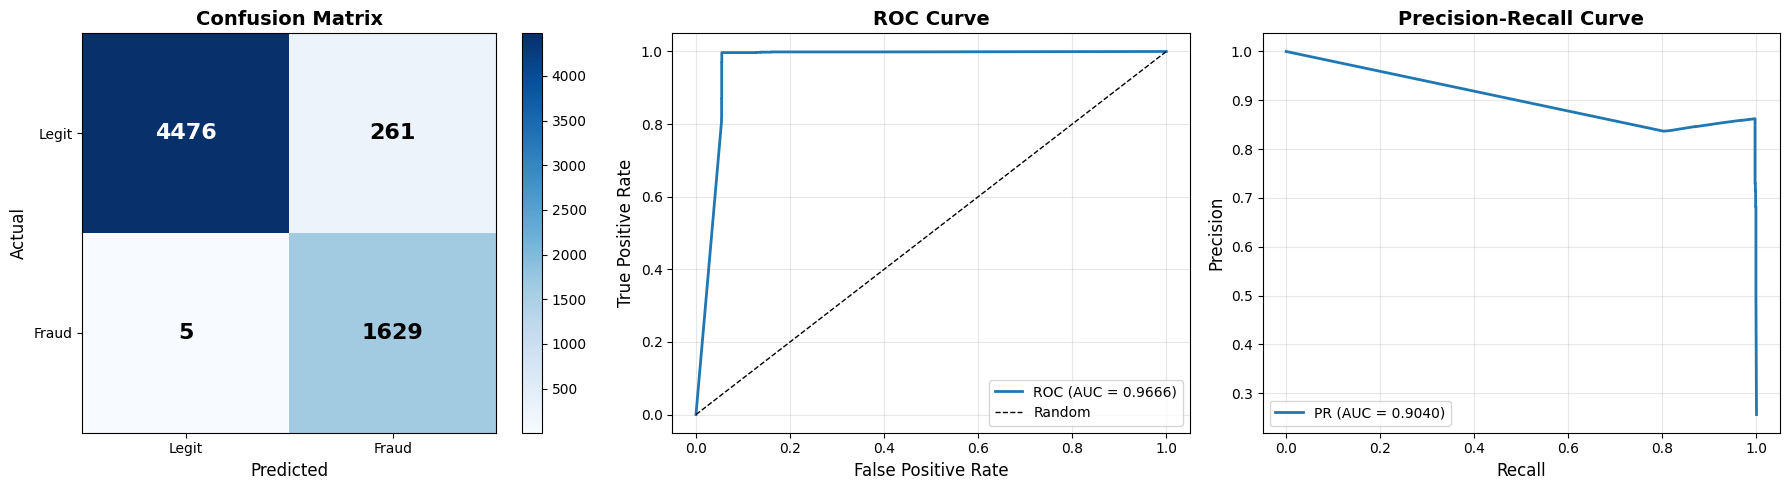


THRESHOLD ANALYSIS

Threshold    Precision    Recall       F1-Score    
------------------------------------------------------------
0.3          0.8619       0.9969       0.9245      
0.4          0.8619       0.9969       0.9245      
0.5          0.8619       0.9969       0.9245      
0.6          0.8619       0.9969       0.9245      
0.7          0.8619       0.9969       0.9245      
0.8          0.8619       0.9969       0.9245      
0.9          0.8624       0.9969       0.9248      


In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# Evaluate on test set
model.eval()
test_preds = []
test_labels = []
test_probs = []

# Create test loader
test_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=('customer', test_mask),
    shuffle=False,
    num_workers=0
)

print("Evaluating on test set...")
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict)
        
        # Get predictions for input nodes only
        batch_size_test = batch['customer'].batch_size
        customer_out = out.squeeze()[:batch_size_test]
        probs = torch.sigmoid(customer_out).cpu()
        
        customer_y = batch['customer'].y[:batch_size_test].cpu()  # Move to CPU
        labeled_mask = customer_y != -1
        
        if labeled_mask.sum() > 0:
            test_probs.extend(probs[labeled_mask].tolist())
            test_preds.extend((probs[labeled_mask] > 0.5).float().tolist())
            test_labels.extend(customer_y[labeled_mask].tolist())

# Convert to numpy arrays
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

# Calculate metrics
print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"\nTotal test samples: {len(test_labels)}")
print(f"Fraud samples: {(test_labels == 1).sum()}")
print(f"Legit samples: {(test_labels == 0).sum()}")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(test_labels, test_preds, target_names=['Legit', 'Fraud'], digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print("\n" + "-"*60)
print("Confusion Matrix:")
print("-"*60)
print(f"                 Predicted Legit  Predicted Fraud")
print(f"Actual Legit     {cm[0,0]:>15}  {cm[0,1]:>15}")
print(f"Actual Fraud     {cm[1,0]:>15}  {cm[1,1]:>15}")

# ROC-AUC
roc_auc = roc_auc_score(test_labels, test_probs)
print(f"\n{'ROC-AUC Score:':<30} {roc_auc:.4f}")

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = auc(recall, precision)
print(f"{'Precision-Recall AUC:':<30} {pr_auc:.4f}")

# Additional fraud-specific metrics
fraud_recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
fraud_precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
print(f"{'Fraud Detection Rate:':<30} {fraud_recall:.4f} ({cm[1,1]}/{cm[1,1] + cm[1,0]} frauds caught)")
print(f"{'Fraud Precision:':<30} {fraud_precision:.4f} ({cm[1,1]}/{cm[1,1] + cm[0,1]} correct fraud alerts)")
print("="*60)

# Create visualization of results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Heatmap
im = axes[0].imshow(cm, cmap='Blues', aspect='auto')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Legit', 'Fraud'])
axes[0].set_yticklabels(['Legit', 'Fraud'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = axes[0].text(j, i, f'{cm[i, j]}', ha='center', va='center', 
                           color='white' if cm[i, j] > cm.max() / 2 else 'black',
                           fontsize=16, fontweight='bold')
plt.colorbar(im, ax=axes[0])

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve
axes[2].plot(recall, precision, linewidth=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Threshold analysis
print("\n" + "="*60)
print("THRESHOLD ANALYSIS")
print("="*60)
print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*60)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_thresh = (test_probs > thresh).astype(int)
    tp = ((preds_thresh == 1) & (test_labels == 1)).sum()
    fp = ((preds_thresh == 1) & (test_labels == 0)).sum()
    fn = ((preds_thresh == 0) & (test_labels == 1)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    print(f"{thresh:<12.1f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")
print("="*60)

In [30]:
# Save the trained model
model_path = 'fraud_gat_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'test_roc_auc': roc_auc,
    'test_pr_auc': pr_auc,
    'total_pseudo_labeled': total_pseudo_labeled,
    'model_config': {
        'hidden_channels': 32,
        'out_channels': 1,
        'num_heads': 2
    }
}, model_path)

print(f"✓ Model saved to {model_path}")
print(f"\nModel Performance Summary:")
print(f"  • ROC-AUC: {roc_auc:.4f}")
print(f"  • PR-AUC: {pr_auc:.4f}")
print(f"  • Fraud Detection Rate: {fraud_recall:.4f}")
print(f"  • Total samples trained: {len(test_labels) + len(train_labels)}")
print(f"  • Pseudo-labeled samples: {total_pseudo_labeled}")

# Save pseudo-labeled transactions
customer_labels = pd.Series(
    data['customer'].y.detach().cpu().numpy(),
    index=np.arange(num_cust)
)

pseudo_tx = master_pool[master_pool['is_fraud'] == -1].copy()
pseudo_tx['pseudo_is_fraud'] = pseudo_tx['cust_idx'].map(customer_labels)

# Keep only newly pseudo-labeled transactions
pseudo_tx = pseudo_tx[pseudo_tx['pseudo_is_fraud'] != -1]

pseudo_tx_path = 'pseudo_transaction_pool.csv.gz'
print("Saving pseudo-labeled transactions")
pseudo_tx.to_csv(pseudo_tx_path, index=False, compression='gzip')
print(f"Pseudo-labeled transactions saved to {pseudo_tx_path} ({len(pseudo_tx)} rows)")

✓ Model saved to fraud_gat_model.pth

Model Performance Summary:
  • ROC-AUC: 0.9666
  • PR-AUC: 0.9040
  • Fraud Detection Rate: 0.9969
  • Total samples trained: 58788
  • Pseudo-labeled samples: 58547
✓ Pseudo-labeled transactions saved to pseudo_transaction_pool.csv.gz (5666293 rows)


In [33]:
# Generate predictions for ALL customers (including unlabeled)
print("\n" + "="*60)
print("FULL CUSTOMER BASE FRAUD PREDICTIONS")
print("="*60)

model.eval()
all_customer_probs = torch.zeros(data['customer'].num_nodes)

# Create loader for all customers
full_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=('customer', torch.ones(data['customer'].num_nodes, dtype=torch.bool)),
    shuffle=False,
    num_workers=0
)

with torch.no_grad():
    for batch in full_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict)
        
        batch_size_full = batch['customer'].batch_size
        customer_out = out.squeeze()[:batch_size_full]
        probs = torch.sigmoid(customer_out).cpu()
        
        input_node_ids = batch['customer'].n_id[:batch_size_full]
        all_customer_probs[input_node_ids] = probs

# Analyze predictions
fraud_predictions = (all_customer_probs > 0.5).sum().item()
high_risk = (all_customer_probs > 0.8).sum().item()
medium_risk = ((all_customer_probs > 0.5) & (all_customer_probs <= 0.8)).sum().item()
low_risk = (all_customer_probs <= 0.2).sum().item()

print(f"\nTotal customers analyzed: {data['customer'].num_nodes:,}")
print(f"\nRisk Distribution:")
print(f"  • High Risk (>80% fraud prob):   {high_risk:>6,} customers ({high_risk/data['customer'].num_nodes*100:>5.2f}%)")
print(f"  • Medium Risk (50-80%):          {medium_risk:>6,} customers ({medium_risk/data['customer'].num_nodes*100:>5.2f}%)")
print(f"  • Low Risk (<20%):               {low_risk:>6,} customers ({low_risk/data['customer'].num_nodes*100:>5.2f}%)")
print(f"\nTotal flagged as fraud (>50%):   {fraud_predictions:>6,} customers ({fraud_predictions/data['customer'].num_nodes*100:>5.2f}%)")

# Show distribution of fraud probabilities
print("\n" + "-"*60)
print("Fraud Probability Distribution:")
print("-"*60)
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
hist, _ = np.histogram(all_customer_probs.numpy(), bins=bins)
for i, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
    bar = '█' * int(hist[i] / max(hist) * 40)
    print(f"  {low:.1f}-{high:.1f}: {hist[i]:>6,} {bar}")

print("="*60)
print("\n✓ Evaluation complete!")

# Build output for KYC customers only
kyc_ind = pd.read_csv(os.path.join(data_path, 'kyc_individual.csv.gz'), usecols=['customer_id'])
kyc_biz = pd.read_csv(os.path.join(data_path, 'kyc_smallbusiness.csv.gz'), usecols=['customer_id'])

kyc_ids = pd.concat([kyc_ind['customer_id'], kyc_biz['customer_id']]).astype(str).unique()
kyc_df = pd.DataFrame({'customer_id': kyc_ids})
kyc_df['cust_idx'] = kyc_df['customer_id'].map(cust_map)

all_probs_np = all_customer_probs.cpu().numpy()
kyc_df['risk_score'] = kyc_df['cust_idx'].apply(
    lambda idx: float(all_probs_np[int(idx)]) if pd.notna(idx) else 0.0
)
kyc_df['predicted_label'] = (kyc_df['risk_score'] > 0.5).astype(int)

output_df = kyc_df[['customer_id', 'predicted_label', 'risk_score']]
output_df.to_csv('model_output.csv', index=False)
print("✓ Saved model_output.csv")


FULL CUSTOMER BASE FRAUD PREDICTIONS


/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(



Total customers analyzed: 65,522

Risk Distribution:
  • High Risk (>80% fraud prob):   19,497 customers (29.76%)
  • Medium Risk (50-80%):             286 customers ( 0.44%)
  • Low Risk (<20%):               45,420 customers (69.32%)

Total flagged as fraud (>50%):   19,783 customers (30.19%)

------------------------------------------------------------
Fraud Probability Distribution:
------------------------------------------------------------
  0.0-0.1: 45,201 ████████████████████████████████████████
  0.1-0.2:    219 
  0.2-0.3:    139 
  0.3-0.4:     89 
  0.4-0.5:     91 
  0.5-0.6:     86 
  0.6-0.7:     99 
  0.7-0.8:    101 
  0.8-0.9:    179 
  0.9-1.0: 19,318 █████████████████

✓ Evaluation complete!
✓ Saved model_output.csv


In [45]:
# Add fraud_probability to master_pool using already-computed all_customer_probs
# This maps customer-level fraud probabilities to each transaction

# Create a mapping from cust_idx to fraud probability
all_probs_np = all_customer_probs.cpu().numpy()
cust_idx_to_prob = {i: float(all_probs_np[i]) for i in range(len(all_probs_np))}

# Map to transactions
master_pool['fraud_probability'] = master_pool['cust_idx'].map(cust_idx_to_prob)

# Check for any missing values
missing_probs = master_pool['fraud_probability'].isna().sum()
if missing_probs > 0:
    print(f"Warning: {missing_probs} transactions missing fraud probability")
    master_pool['fraud_probability'] = master_pool['fraud_probability'].fillna(0.5)
else:
    print(f"✓ Successfully added fraud_probability to {len(master_pool)} transactions")
    print(f"  Probability range: {master_pool['fraud_probability'].min():.4f} to {master_pool['fraud_probability'].max():.4f}")

✓ Successfully added fraud_probability to 6497976 transactions
  Probability range: 0.0000 to 1.0000


In [ ]:
def get_suspicious_legit_customers(master_pool, threshold=0.8):
    # Filter for customers labeled as 'Legit' but predicted as 'Fraud'
    suspicious = master_pool[(master_pool['is_fraud'] == 0) & 
                             (master_pool['fraud_probability'] > threshold)]
    
    # Sort by the highest risk score
    suspicious = suspicious.sort_values(by='fraud_probability', ascending=False)
    
    print(f"Found {len(suspicious['customer_id'].unique())} highly suspicious 'Legit' customers.")
    
    # Summary of their behavior
    summary = suspicious.groupby('customer_id').agg({
        'amount_cad': ['mean', 'sum', 'count'],
        'merchant_category': lambda x: x.mode().iloc[0],
        'city': lambda x: x.mode().iloc[0],
        'fraud_probability': 'max'
    })
    
    return summary.head(10)

# Run this after your final inference pass
top_suspects = get_suspicious_legit_customers(master_pool)
print(top_suspects)

Found 4364 highly suspicious 'Legit' customers.
             amount_cad                   \
                   mean        sum count   
customer_id                                
C1000148617   53.253138  6922.9080   130   
C100045114    75.426421  7844.3478   104   
C1000699316   61.810928  5810.2272    94   
C1001065306  143.004221  2717.0802    19   
C1002658784   55.490318  7269.2316   131   
C1002759277   46.537167  7632.0954   164   
C1004109477   47.384500  7676.2890   162   
C1004300450   54.798989  9809.0190   179   
C1004532392   42.786176  3508.4664    82   
C1005126300   48.480593  8629.5456   178   

                                   merchant_category     city  \
                                            <lambda> <lambda>   
customer_id                                                     
C1000148617                         Taxicab Industry  TORONTO   
C100045114                          Taxicab Industry  TORONTO   
C1000699316                         Taxicab Industry  

In [57]:
from display import visualize_customer_neighborhood

# Try it with your most suspicious customer
visualize_customer_neighborhood("C1001065306", master_pool, customer_pool, data)

✓ Self-contained HTML saved to fraud_map_C1001065306.html
✓ Graph contains 27 nodes and 60 edges
✓ File is ready to copy to another computer (no internet needed)


'fraud_map_C1001065306.html'